In [59]:
# ============================================================
# CARBON EMISSION CLASSIFICATION
# Decision Tree vs Random Forest
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [60]:
# ============================================================
# 2. LOAD DATA
# ============================================================

economic_impact_df = pd.read_csv(
    "../data/economic_impact_on_emissions_modified.csv"
)

co2_emissions_df = pd.read_csv(
    "../data/Carbon_(CO2)_Emissions_by_Country.csv"
)

print("Economic dataset shape:", economic_impact_df.shape)
print("CO2 dataset shape:", co2_emissions_df.shape)

Economic dataset shape: (1000, 7)
CO2 dataset shape: (5677, 5)


In [61]:
# ============================================================
# 3. CREATE EMISSION CATEGORY
# ============================================================

def classify_emissions(emission):
    if emission < 150:
        return "Low"
    elif emission < 300:
        return "Medium"
    else:
        return "High"


economic_impact_df["Emission_Category"] = (
    economic_impact_df["CO2_Emissions"]
    .apply(classify_emissions)
)

In [62]:
# ============================================================
# 4. MERGE DATASETS
# ============================================================

merged_df = pd.merge(
    economic_impact_df,
    co2_emissions_df,
    on="Country",
    how="inner"
)

print("Merged dataset shape:", merged_df.shape)

Merged dataset shape: (27210, 11)


In [63]:
# ============================================================
# 5. BASIC DATA QUALITY CHECK
# ============================================================

print("\nDuplicate rows:")
print(merged_df.duplicated().sum())

print("\nMissing values:")
print(merged_df.isnull().sum())


Duplicate rows:
0

Missing values:
Country                      0
GDP_per_Capita            1350
Fuel_Price                1350
Population_Density        1320
Urbanization_Rate         1410
CO2_Emissions             1380
Emission_Category            0
Region                       0
Date                         0
Kilotons of Co2              0
Metric Tons Per Capita       0
dtype: int64


In [66]:
# ============================================================
# 6. HANDLE MISSING VALUES
# ============================================================

numeric_cols = merged_df.select_dtypes(
    include=["number"]
).columns

categorical_cols = merged_df.select_dtypes(
    include=["object"]
).columns

# Fill numeric missing values with median
for column in numeric_cols:
    merged_df[column] = merged_df[column].fillna(
        merged_df[column].median()
    )

# Fill categorical missing values with mode
for column in categorical_cols:
    if merged_df[column].isnull().any():
        merged_df[column] = merged_df[column].fillna(
            merged_df[column].mode()[0]
        )


# Verify missing values after cleaning
print("\nMissing values after cleaning:")
print(merged_df.isnull().sum().sum())


Missing values after cleaning:
0


C:\Users\Sidqi\AppData\Local\Temp\ipykernel_17448\1372551722.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = merged_df.select_dtypes(


In [67]:
# ============================================================
# 7. TARGET DISTRIBUTION
# ============================================================

print("\nEmission Category Distribution:")
print(merged_df["Emission_Category"].value_counts())

print("\nEmission Category Proportion:")
print(
    merged_df["Emission_Category"]
    .value_counts(normalize=True)
)


Emission Category Distribution:
Emission_Category
High      13260
Medium     8460
Low        5490
Name: count, dtype: int64

Emission Category Proportion:
Emission_Category
High      0.487321
Medium    0.310915
Low       0.201764
Name: proportion, dtype: float64


In [68]:
# ============================================================
# 8. DEFINE FEATURES AND TARGET
# ============================================================
#
# IMPORTANT:
#
# CO2_Emissions is excluded because it is directly used
# to create Emission_Category.
#
# Kilotons of Co2 and Metric Tons Per Capita are also
# excluded because they are direct emission measurements
# and can act as proxies for the target.
#
# Country, Region, and Date are excluded to keep the model
# focused on economic and demographic indicators.
#
# ============================================================

features = [
    "GDP_per_Capita",
    "Fuel_Price",
    "Population_Density",
    "Urbanization_Rate"
]

X = merged_df[features]
y = merged_df["Emission_Category"]

print("\nFeatures used for modeling:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)


Features used for modeling:
['GDP_per_Capita', 'Fuel_Price', 'Population_Density', 'Urbanization_Rate']

Target:
Emission_Category


In [69]:
# ============================================================
# 9. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (21768, 4)
Testing data: (5442, 4)


In [70]:
# ============================================================
# 10. DECISION TREE
# ============================================================

dt_model = DecisionTreeClassifier(
    max_depth=2,
    min_samples_split=20,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [71]:
# ============================================================
# 11. RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [72]:
# ============================================================
# 12. DECISION TREE EVALUATION
# ============================================================

print("=" * 60)
print("DECISION TREE")
print("=" * 60)

print(
    classification_report(
        y_test,
        dt_pred
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        dt_pred
    )
)

DECISION TREE
              precision    recall  f1-score   support

        High       0.50      0.98      0.66      2652
         Low       0.49      0.10      0.16      1098
      Medium       0.00      0.00      0.00      1692

    accuracy                           0.50      5442
   macro avg       0.33      0.36      0.27      5442
weighted avg       0.34      0.50      0.36      5442

Confusion Matrix:
[[2611   41    0]
 [ 992  106    0]
 [1624   68    0]]


d:\electricity-bill-increase-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\electricity-bill-increase-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\electricity-bill-increase-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [73]:
# ============================================================
# 13. RANDOM FOREST EVALUATION
# ============================================================

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        rf_pred
    )
)

RANDOM FOREST
              precision    recall  f1-score   support

        High       0.52      1.00      0.68      2652
         Low       1.00      0.12      0.22      1098
      Medium       0.94      0.13      0.22      1692

    accuracy                           0.55      5442
   macro avg       0.82      0.42      0.38      5442
weighted avg       0.75      0.55      0.45      5442

Confusion Matrix:
[[2643    0    9]
 [ 957  137    4]
 [1478    0  214]]


In [74]:
# ============================================================
# 14. MODEL PERFORMANCE SUMMARY
# ============================================================

models = {
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

results = []

for model_name, predictions in models.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Weighted Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Weighted Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ),
        "Weighted F1-Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

print("=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

MODEL PERFORMANCE SUMMARY
        Model  Accuracy  Weighted Precision  Weighted Recall  Weighted F1-Score
Decision Tree    0.4993              0.3429           0.4993             0.3556
Random Forest    0.5502              0.7485           0.5502             0.4474


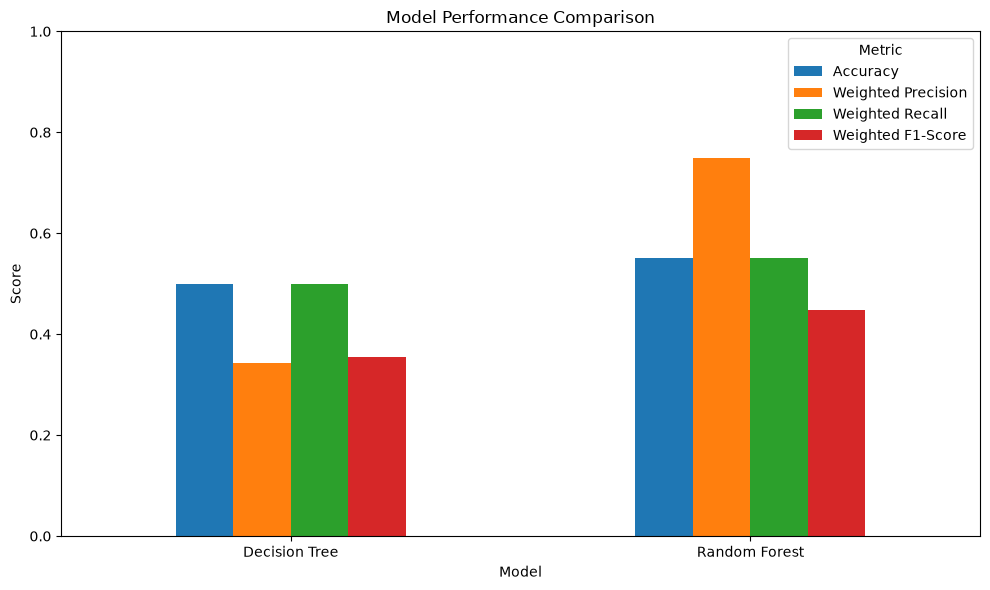

In [75]:
# ============================================================
# 15. MODEL COMPARISON
# ============================================================

metrics = [
    "Accuracy",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1-Score"
]

results_plot = results_df.set_index("Model")[metrics]

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

RANDOM FOREST FEATURE IMPORTANCE
GDP_per_Capita        0.289572
Population_Density    0.274050
Urbanization_Rate     0.250206
Fuel_Price            0.186172
dtype: float64


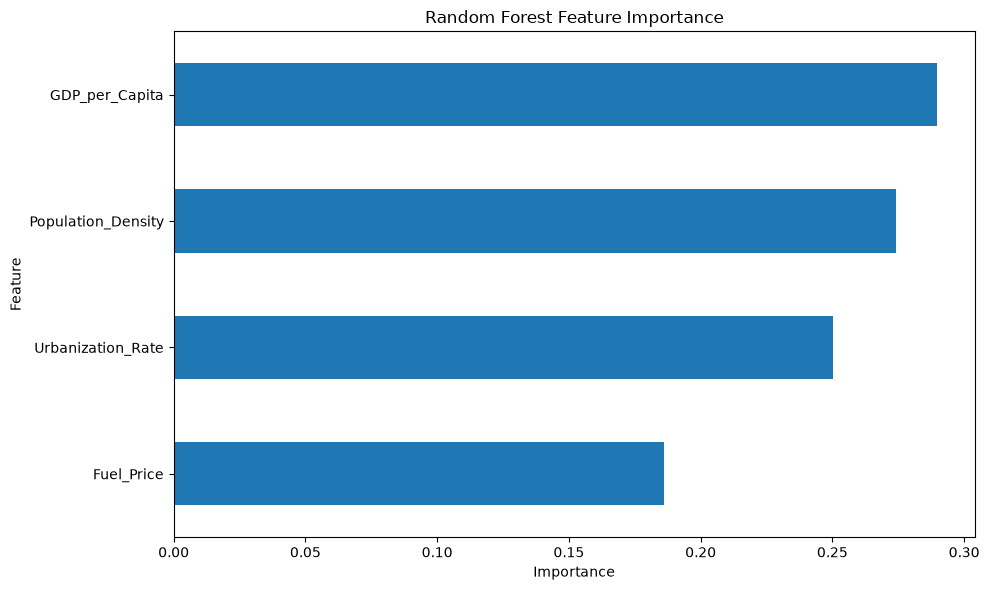

In [76]:
# ============================================================
# 16. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

print("=" * 60)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 60)

print(feature_importance)


# Plot feature importance

plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

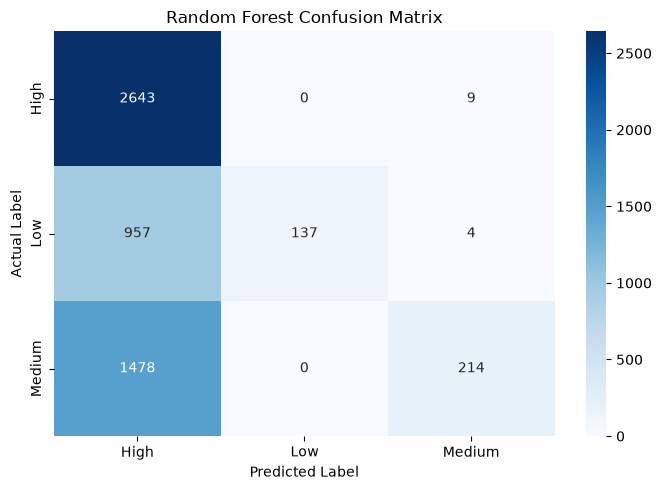

In [77]:
# ============================================================
# 17. FINAL CONFUSION MATRIX - RANDOM FOREST
# ============================================================

rf_cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["High", "Low", "Medium"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["High", "Low", "Medium"],
    yticklabels=["High", "Low", "Medium"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [78]:
# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print(f"Dataset size : {len(merged_df):,} rows")
print(f"Features     : {', '.join(features)}")
print(f"Target       : Emission_Category")
print(f"DT Accuracy  : {results_df.loc[0, 'Accuracy']:.4f}")
print(f"RF Accuracy  : {results_df.loc[1, 'Accuracy']:.4f}")

FINAL PROJECT SUMMARY
Dataset size : 27,210 rows
Features     : GDP_per_Capita, Fuel_Price, Population_Density, Urbanization_Rate
Target       : Emission_Category
DT Accuracy  : 0.4993
RF Accuracy  : 0.5502
